In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind # For t-tests

# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the dataset
try:
    df = pd.read_csv(r'C:\Users\Hp\Downloads\QVI_data.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: QVI_data.csv not found. Please ensure the file is in the correct directory.")
    # Exit or handle the error appropriately if the file isn't found
    exit()

# Display the first few rows and basic info to understand the data
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!

First 5 rows of the dataset:
   LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0            1000  2018-10-17          1       1         5   
1            1002  2018-09-16          1       2        58   
2            1003  2019-03-07          1       3        52   
3            1003  2019-03-08          1       4       106   
4            1004  2018-11-02          1       5        96   

                                PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0  Natural Chip        Compny SeaSalt175g         2        6.0        175   
1   Red Rock Deli Chikn&Garlic Aioli 150g         1        2.7        150   
2   Grain Waves Sour    Cream&Chives 210G         1        3.6        210   
3  Natural ChipCo      Hony Soy Chckn175g         1        3.0        175   
4          WW Original Stacked Chips 160g         1        1.9        160   

        BRAND              LIFESTAGE PREMIUM_CUSTOMER  
0     NATURAL  YOUNG SINGLES/COUPLES          Pre

In [2]:
# Convert DATE to datetime objects
df['DATE'] = pd.to_datetime(df['DATE'])

# Create a month-year column for aggregation
df['MONTH_YEAR'] = df['DATE'].dt.to_period('M')

# Calculate total sales revenue per store per month
monthly_sales = df.groupby(['STORE_NBR', 'MONTH_YEAR'])['TOT_SALES'].sum().reset_index()
monthly_sales.rename(columns={'TOT_SALES': 'MONTHLY_SALES'}, inplace=True)

# Calculate total number of customers per store per month
monthly_customers = df.groupby(['STORE_NBR', 'MONTH_YEAR'])['LYLTY_CARD_NBR'].nunique().reset_index()
monthly_customers.rename(columns={'LYLTY_CARD_NBR': 'MONTHLY_CUSTOMERS'}, inplace=True)

# Calculate average number of transactions per customer per store per month
# First, count transactions per customer per month
transactions_per_customer = df.groupby(['STORE_NBR', 'MONTH_YEAR', 'LYLTY_CARD_NBR']).size().reset_index(name='TRANSACTION_COUNT')
# Then, average these counts per store per month
monthly_avg_transactions_per_customer = transactions_per_customer.groupby(['STORE_NBR', 'MONTH_YEAR'])['TRANSACTION_COUNT'].mean().reset_index()
monthly_avg_transactions_per_customer.rename(columns={'TRANSACTION_COUNT': 'AVG_TRANSACTIONS_PER_CUSTOMER'}, inplace=True)

# Merge these aggregated metrics into a single DataFrame
store_monthly_metrics = pd.merge(monthly_sales, monthly_customers, on=['STORE_NBR', 'MONTH_YEAR'])
store_monthly_metrics = pd.merge(store_monthly_metrics, monthly_avg_transactions_per_customer, on=['STORE_NBR', 'MONTH_YEAR'])

print("\nMonthly aggregated metrics for stores:")
print(store_monthly_metrics.head())


Monthly aggregated metrics for stores:
   STORE_NBR MONTH_YEAR  MONTHLY_SALES  MONTHLY_CUSTOMERS  \
0          1    2018-07          206.9                 49   
1          1    2018-08          176.1                 42   
2          1    2018-09          278.8                 59   
3          1    2018-10          188.1                 44   
4          1    2018-11          192.6                 46   

   AVG_TRANSACTIONS_PER_CUSTOMER  
0                       1.061224  
1                       1.023810  
2                       1.050847  
3                       1.022727  
4                       1.021739  


In [3]:
# Define trial stores
trial_stores = [77, 86, 88]

# Define trial period (adjust these dates based on actual data if different)
# Assuming a 3-month trial period starting Feb 2019
pre_trial_end = pd.Period('2019-01', 'M')
trial_start = pd.Period('2019-02', 'M')
trial_end = pd.Period('2019-04', 'M')

# Filter out trial stores from the main dataset for control selection
control_candidate_stores_metrics = store_monthly_metrics[~store_monthly_metrics['STORE_NBR'].isin(trial_stores)].copy()

# Identify all unique store numbers excluding trial stores
all_stores_excluding_trial = store_monthly_metrics[~store_monthly_metrics['STORE_NBR'].isin(trial_stores)]['STORE_NBR'].unique()

print(f"\nTrial Stores: {trial_stores}")
print(f"Pre-Trial End Month: {pre_trial_end}")
print(f"Trial Start Month: {trial_start}")
print(f"Trial End Month: {trial_end}")


Trial Stores: [77, 86, 88]
Pre-Trial End Month: 2019-01
Trial Start Month: 2019-02
Trial End Month: 2019-04


In [4]:
def select_control_store(trial_store_nbr, metrics_df, pre_trial_end_month):
    """
    Selects the best control store for a given trial store based on pre-trial metrics.

    Args:
        trial_store_nbr (int): The store number of the trial store.
        metrics_df (pd.DataFrame): DataFrame containing monthly metrics for all stores.
        pre_trial_end_month (pd.Period): The last month of the pre-trial period.

    Returns:
        int: The store number of the selected control store.
        pd.DataFrame: A DataFrame showing similarity scores for candidate control stores.
    """
    trial_store_data = metrics_df[(metrics_df['STORE_NBR'] == trial_store_nbr) &
                                  (metrics_df['MONTH_YEAR'] <= pre_trial_end_month)].copy()

    # Exclude the trial store itself and other trial stores from control candidates
    candidate_control_stores_data = metrics_df[~metrics_df['STORE_NBR'].isin(trial_stores) &
                                               (metrics_df['MONTH_YEAR'] <= pre_trial_end_month)].copy()

    if trial_store_data.empty:
        print(f"No pre-trial data for trial store {trial_store_nbr}. Cannot select control.")
        return None, None

    # Pivot the data for correlation calculation
    trial_store_pivot = trial_store_data.pivot(index='MONTH_YEAR', columns='STORE_NBR', values='MONTHLY_SALES')
    candidate_control_pivot = candidate_control_stores_data.pivot(index='MONTH_YEAR', columns='STORE_NBR', values='MONTHLY_SALES')

    # Align indices (months) to ensure correct correlation calculation
    common_months = trial_store_pivot.index.intersection(candidate_control_pivot.index)
    if common_months.empty:
        print(f"No common pre-trial months between trial store {trial_store_nbr} and control candidates. Cannot select control.")
        return None, None

    trial_store_pivot_aligned = trial_store_pivot.loc[common_months]
    candidate_control_pivot_aligned = candidate_control_pivot.loc[common_months]

    # Calculate Pearson correlation for monthly sales
    correlation_scores = {}
    for control_store_nbr in candidate_control_pivot_aligned.columns:
        if trial_store_pivot_aligned[trial_store_nbr].isnull().all() or candidate_control_pivot_aligned[control_store_nbr].isnull().all():
            correlation_scores[control_store_nbr] = -1 # Assign a low correlation if data is missing
        else:
            correlation = trial_store_pivot_aligned[trial_store_nbr].corr(candidate_control_pivot_aligned[control_store_nbr])
            correlation_scores[control_store_nbr] = correlation if not pd.isna(correlation) else -1 # Handle NaN correlation

    correlation_df = pd.DataFrame(list(correlation_scores.items()), columns=['Control_Store_NBR', 'Pearson_Correlation'])

    # Optional: Also consider magnitude distance on average sales/customers/transactions
    # This can be used as a secondary sorting or a combined score
    pre_trial_avg_metrics_trial = trial_store_data[['MONTHLY_SALES', 'MONTHLY_CUSTOMERS', 'AVG_TRANSACTIONS_PER_CUSTOMER']].mean().values
    pre_trial_avg_metrics_control_candidates = candidate_control_stores_data.groupby('STORE_NBR')[['MONTHLY_SALES', 'MONTHLY_CUSTOMERS', 'AVG_TRANSACTIONS_PER_CUSTOMER']].mean()

    distance_scores = {}
    for control_store_nbr in pre_trial_avg_metrics_control_candidates.index:
        control_metrics = pre_trial_avg_metrics_control_candidates.loc[control_store_nbr].values
        # Using Euclidean distance
        distance = np.linalg.norm(pre_trial_avg_metrics_trial - control_metrics)
        distance_scores[control_store_nbr] = distance

    distance_df = pd.DataFrame(list(distance_scores.items()), columns=['Control_Store_NBR', 'Euclidean_Distance'])

    # Merge correlation and distance scores
    similarity_df = pd.merge(correlation_df, distance_df, on='Control_Store_NBR')

    # Sort by correlation (descending) and then distance (ascending) to find the best control
    similarity_df['Rank_Correlation'] = similarity_df['Pearson_Correlation'].rank(ascending=False)
    similarity_df['Rank_Distance'] = similarity_df['Euclidean_Distance'].rank(ascending=True)

    # A simple combined rank or just pick top by correlation
    similarity_df['Combined_Rank'] = similarity_df['Rank_Correlation'] + similarity_df['Rank_Distance']
    similarity_df = similarity_df.sort_values(by=['Pearson_Correlation', 'Euclidean_Distance'], ascending=[False, True])

    best_control_store = similarity_df.iloc[0]['Control_Store_NBR'] if not similarity_df.empty else None

    return int(best_control_store) if best_control_store is not None else None, similarity_df

In [5]:
# Store the selected control stores
selected_controls = {}
similarity_data = {}

for trial_store in trial_stores:
    control, sim_df = select_control_store(trial_store, store_monthly_metrics, pre_trial_end)
    selected_controls[trial_store] = control
    similarity_data[trial_store] = sim_df
    print(f"\nFor Trial Store {trial_store}, selected Control Store: {control}")
    print(f"Top 5 control candidates for Store {trial_store}:\n", sim_df.head())

print("\nSelected Control Stores:")
for trial, control in selected_controls.items():
    print(f"Trial Store {trial}: Control Store {control}")

C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



For Trial Store 77, selected Control Store: 31
Top 5 control candidates for Store 77:
      Control_Store_NBR  Pearson_Correlation  Euclidean_Distance  \
30                  31             1.000000          238.983050   
10                  11             1.000000          242.971905   
70                  71             0.914106          706.579047   
228                233             0.903774            5.601856   
114                119             0.867664          730.659214   

     Rank_Correlation  Rank_Distance  Combined_Rank  
30                1.0          124.0          125.0  
10                2.0          127.0          129.0  
70                3.0          208.0          211.0  
228               4.0            3.0            7.0  
114               5.0          218.0          223.0  


C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



For Trial Store 86, selected Control Store: 31
Top 5 control candidates for Store 86:
      Control_Store_NBR  Pearson_Correlation  Euclidean_Distance  \
30                  31             1.000000          872.450622   
150                155             0.877882           26.978597   
127                132             0.846517          840.611968   
235                240             0.825066          478.997102   
217                222             0.795075           21.567759   

     Rank_Correlation  Rank_Distance  Combined_Rank  
30                1.0          262.0          263.0  
150               2.0           29.0           31.0  
127               3.0          239.0          242.0  
235               4.0          156.0          160.0  
217               5.0           23.0           28.0  


C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Hp\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



For Trial Store 88, selected Control Store: 159
Top 5 control candidates for Store 88:
      Control_Store_NBR  Pearson_Correlation  Euclidean_Distance  \
154                159             0.903186         1320.958208   
199                204             0.885774         1305.826569   
129                134             0.864293          907.575562   
0                    1             0.813636         1145.213477   
248                253             0.811838          927.367611   

     Rank_Correlation  Rank_Distance  Combined_Rank  
154               1.0          251.0          252.0  
199               2.0          238.0          240.0  
129               3.0          146.0          149.0  
0                 4.0          216.0          220.0  
248               5.0          151.0          156.0  

Selected Control Stores:
Trial Store 77: Control Store 31
Trial Store 86: Control Store 31
Trial Store 88: Control Store 159


In [7]:
store_monthly_metrics['MONTH_YEAR_DT'] = store_monthly_metrics['MONTH_YEAR'].dt.to_timestamp()

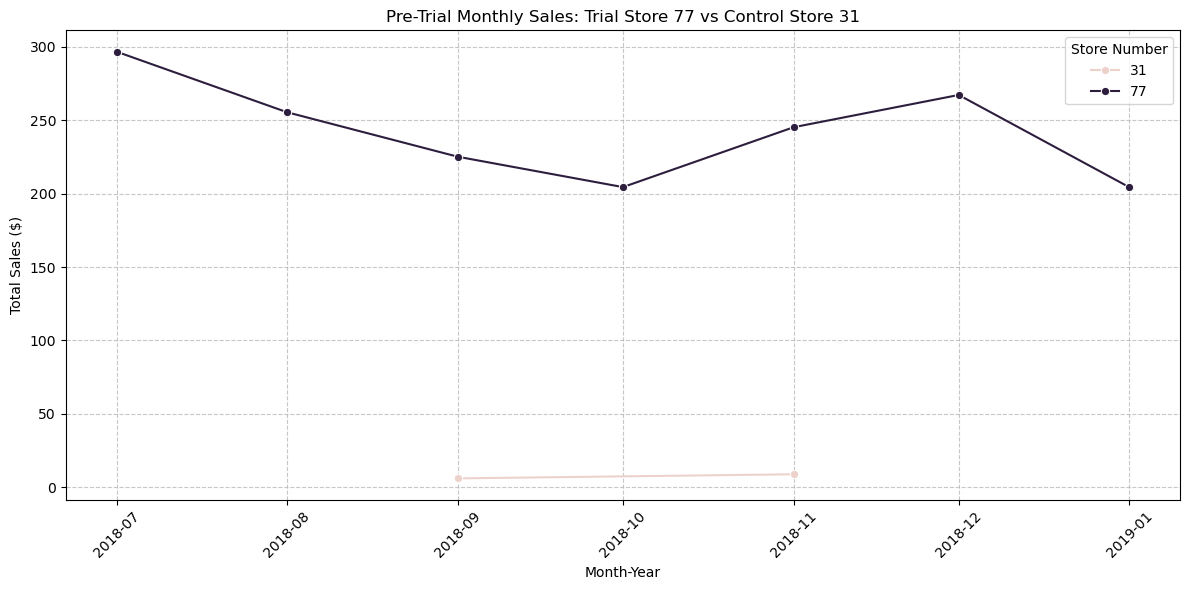

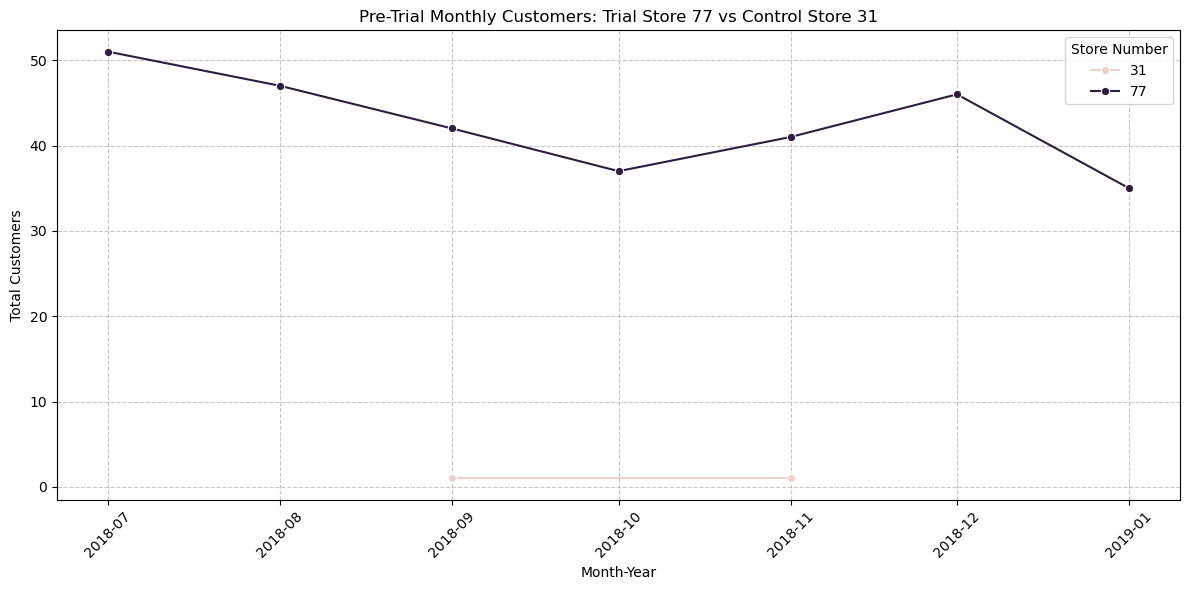

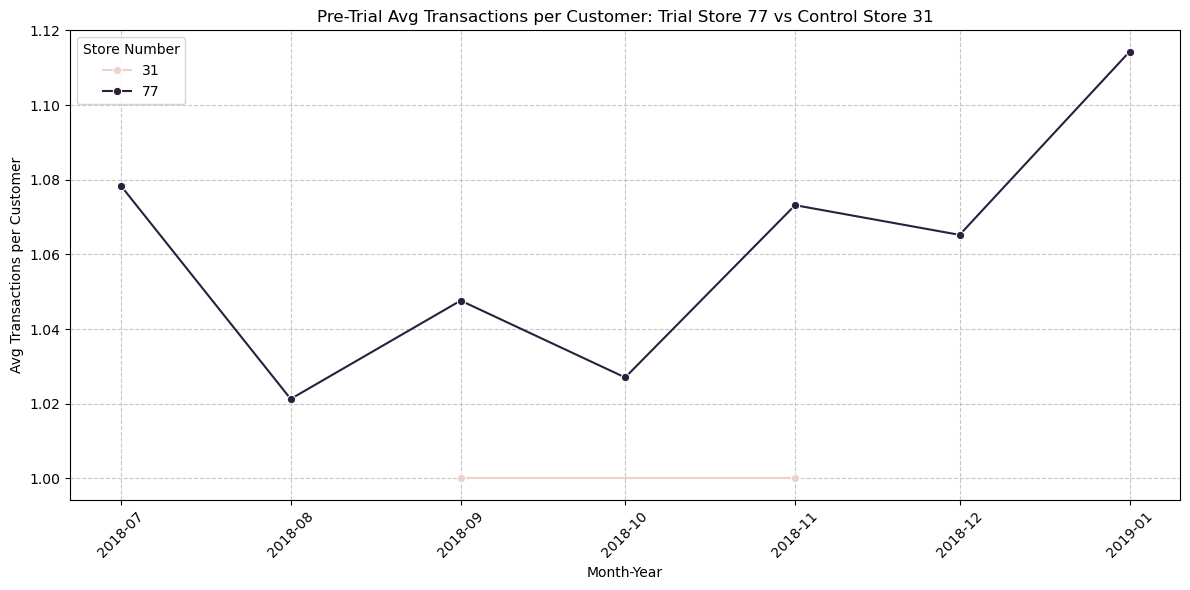

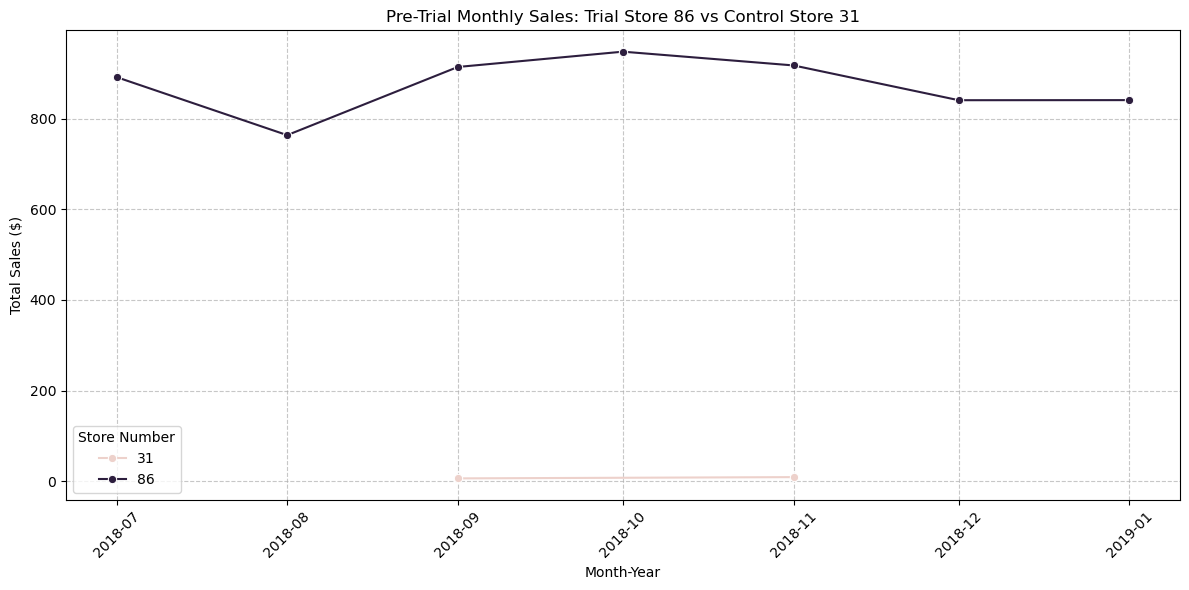

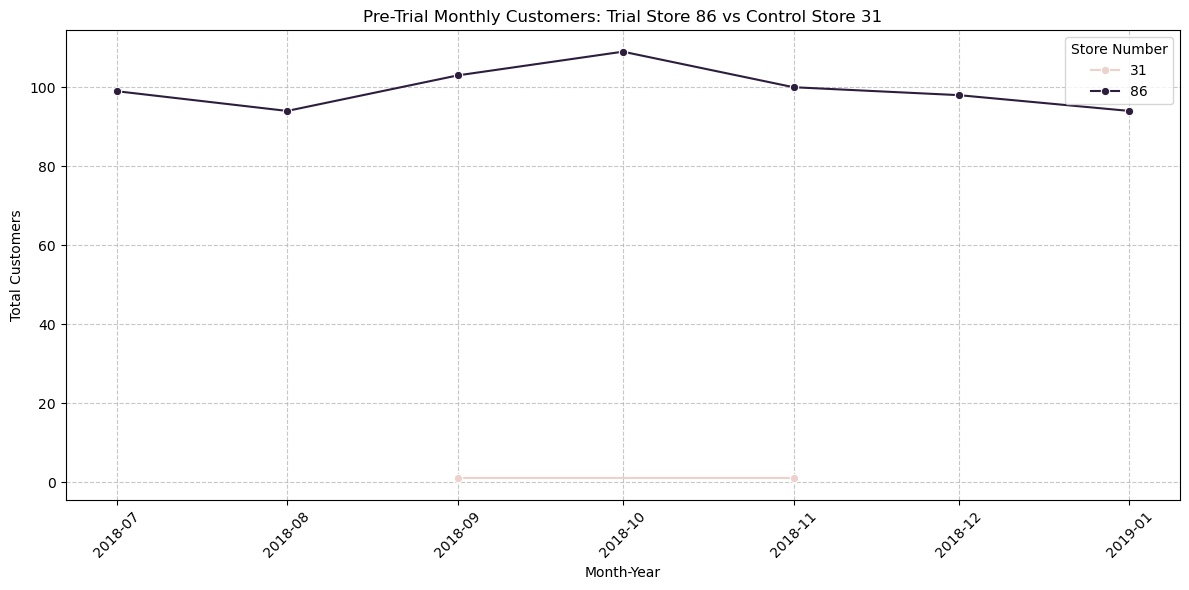

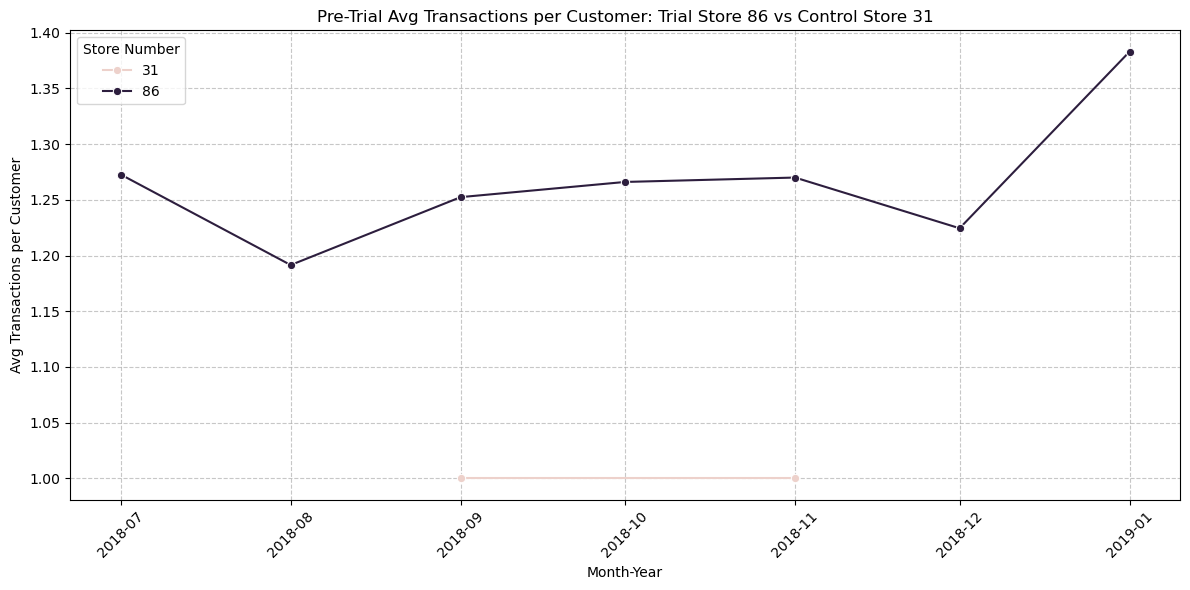

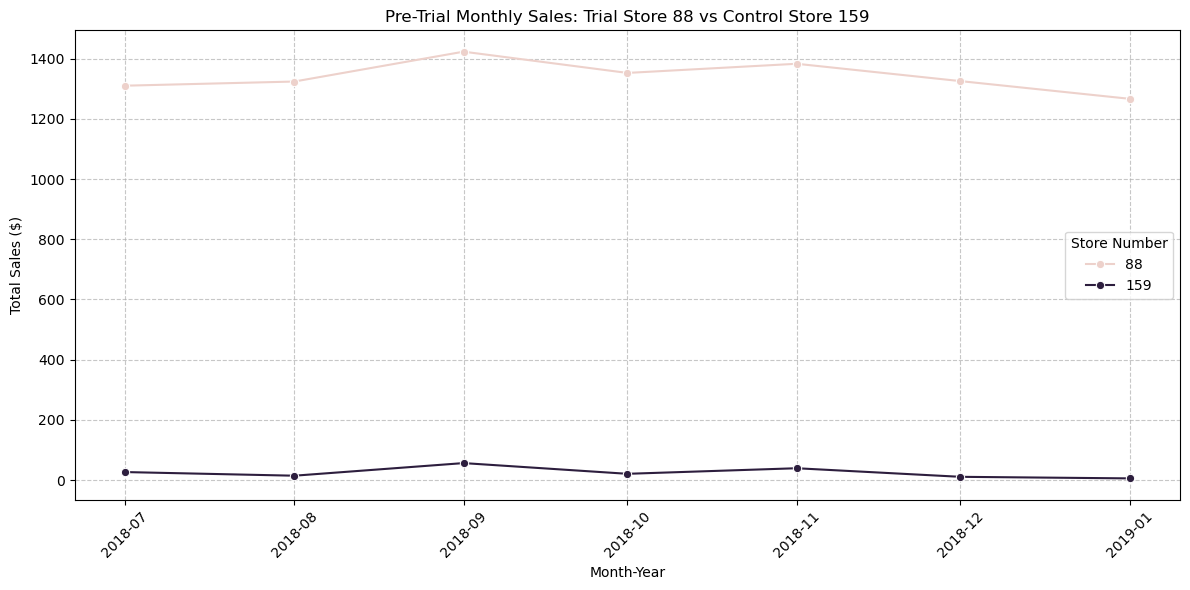

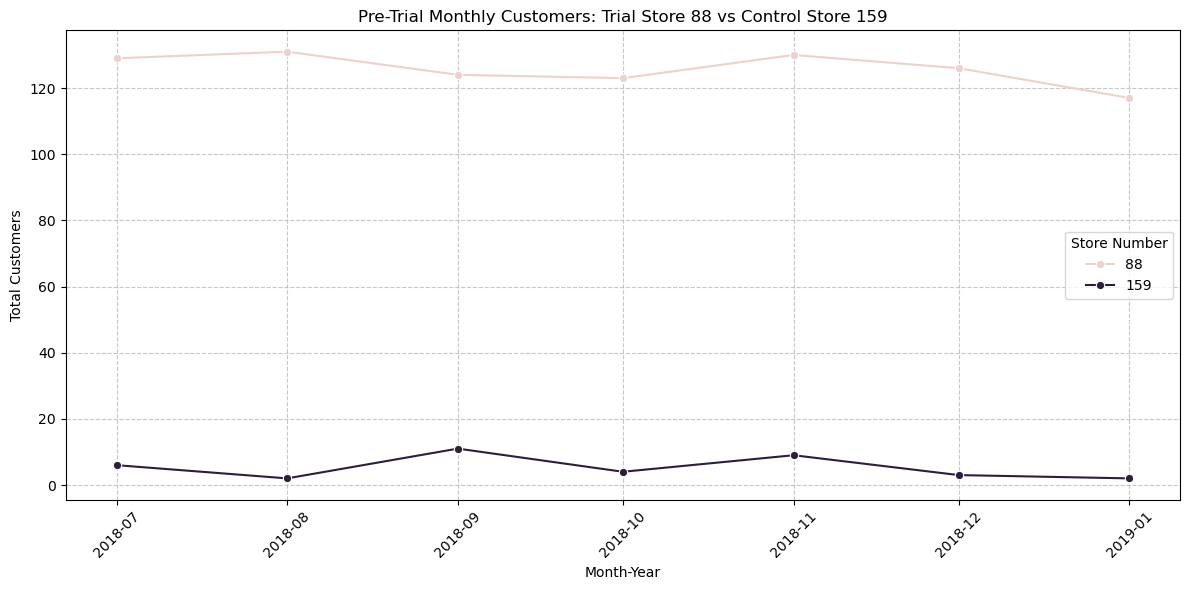

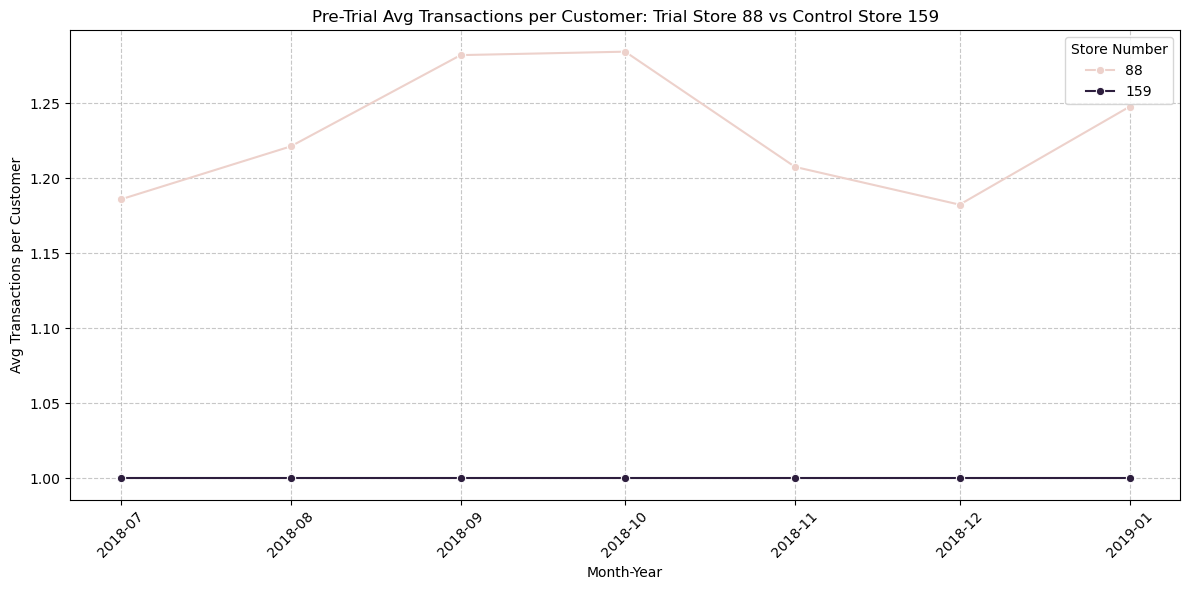

In [9]:
# Visualize pre-trial sales for trial and control stores
for trial_store, control_store in selected_controls.items():
    if control_store is None:
        print(f"Skipping visualization for Trial Store {trial_store} due to no control store selected.")
        continue

    plt.figure(figsize=(12, 6))
    
    # Filter data for the trial and control store for the pre-trial period
    pre_trial_data = store_monthly_metrics[
        ((store_monthly_metrics['STORE_NBR'] == trial_store) | (store_monthly_metrics['STORE_NBR'] == control_store)) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]
    
    sns.lineplot(data=pre_trial_data, x='MONTH_YEAR_DT', y='MONTHLY_SALES', hue='STORE_NBR', marker='o')
    plt.title(f'Pre-Trial Monthly Sales: Trial Store {trial_store} vs Control Store {control_store}')
    plt.xlabel('Month-Year')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45)
    plt.legend(title='Store Number')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'pre_trial_sales_store_{trial_store}.png') # Save the plot
    plt.show()

    # You can extend this to visualize customers and transactions too
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=pre_trial_data, x='MONTH_YEAR_DT', y='MONTHLY_CUSTOMERS', hue='STORE_NBR', marker='o')
    plt.title(f'Pre-Trial Monthly Customers: Trial Store {trial_store} vs Control Store {control_store}')
    plt.xlabel('Month-Year')
    plt.ylabel('Total Customers')
    plt.xticks(rotation=45)
    plt.legend(title='Store Number')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'pre_trial_customers_store_{trial_store}.png')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=pre_trial_data, x='MONTH_YEAR_DT', y='AVG_TRANSACTIONS_PER_CUSTOMER', hue='STORE_NBR', marker='o')
    plt.title(f'Pre-Trial Avg Transactions per Customer: Trial Store {trial_store} vs Control Store {control_store}')
    plt.xlabel('Month-Year')
    plt.ylabel('Avg Transactions per Customer')
    plt.xticks(rotation=45)
    plt.legend(title='Store Number')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'pre_trial_avg_transactions_store_{trial_store}.png')
    plt.show()

In [10]:
print("\n--- Summary of Findings and Recommendations ---")

for trial_store, control_store in selected_controls.items():
    if control_store is None:
        print(f"\nStore {trial_store}: No control store could be identified. Cannot provide a conclusive recommendation.")
        continue

    print(f"\n**Trial Store: {trial_store} (Control Store: {control_store})**")

    # Recalculate key metrics for easy summary
    trial_period_data = store_monthly_metrics[
        (store_monthly_metrics['MONTH_YEAR'] >= trial_start) &
        (store_monthly_metrics['MONTH_YEAR'] <= trial_end)
    ]
    trial_store_trial_data = trial_period_data[trial_period_data['STORE_NBR'] == trial_store]
    control_store_trial_data = trial_period_data[trial_period_data['STORE_NBR'] == control_store]

    # Uplift calculations (copying from previous section for clarity)
    pre_trial_trial_sales_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == trial_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['MONTHLY_SALES'].mean()
    pre_trial_control_sales_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == control_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['MONTHLY_SALES'].mean()
    normalization_factor_sales = pre_trial_trial_sales_avg / pre_trial_control_sales_avg if pre_trial_control_sales_avg != 0 else 1

    trial_sales_total = trial_store_trial_data['MONTHLY_SALES'].sum()
    adjusted_control_sales_total = control_store_trial_data['MONTHLY_SALES'].sum() * normalization_factor_sales
    sales_uplift_percent = ((trial_sales_total - adjusted_control_sales_total) / adjusted_control_sales_total) * 100 if adjusted_control_sales_total != 0 else np.nan

    pre_trial_trial_customers_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == trial_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['MONTHLY_CUSTOMERS'].mean()
    pre_trial_control_customers_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == control_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['MONTHLY_CUSTOMERS'].mean()
    normalization_factor_customers = pre_trial_trial_customers_avg / pre_trial_control_customers_avg if pre_trial_control_customers_avg != 0 else 1

    trial_customers_total = trial_store_trial_data['MONTHLY_CUSTOMERS'].sum()
    adjusted_control_customers_total = control_store_trial_data['MONTHLY_CUSTOMERS'].sum() * normalization_factor_customers
    customer_uplift_percent = ((trial_customers_total - adjusted_control_customers_total) / adjusted_control_customers_total) * 100 if adjusted_control_customers_total != 0 else np.nan

    pre_trial_trial_avg_trans_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == trial_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['AVG_TRANSACTIONS_PER_CUSTOMER'].mean()
    pre_trial_control_avg_trans_avg = store_monthly_metrics[
        (store_monthly_metrics['STORE_NBR'] == control_store) &
        (store_monthly_metrics['MONTH_YEAR'] <= pre_trial_end)
    ]['AVG_TRANSACTIONS_PER_CUSTOMER'].mean()
    normalization_factor_avg_trans = pre_trial_trial_avg_trans_avg / pre_trial_control_avg_trans_avg if pre_trial_control_avg_trans_avg != 0 else 1

    trial_avg_transactions = trial_store_trial_data['AVG_TRANSACTIONS_PER_CUSTOMER'].mean()
    adjusted_control_avg_transactions = control_store_trial_data['AVG_TRANSACTIONS_PER_CUSTOMER'].mean() * normalization_factor_avg_trans
    avg_trans_uplift_percent = ((trial_avg_transactions - adjusted_control_avg_transactions) / adjusted_control_avg_transactions) * 100 if adjusted_control_avg_transactions != 0 else np.nan


    print(f"  - Sales Uplift: {sales_uplift_percent:.2f}%")
    print(f"  - Customer Uplift: {customer_uplift_percent:.2f}%")
    print(f"  - Average Transactions per Customer Uplift: {avg_trans_uplift_percent:.2f}%")

    # T-test for sales (re-running for summary consistency)
    if len(trial_store_trial_data) > 1 and len(control_store_trial_data) > 1:
        t_stat_sales, p_value_sales = ttest_ind(trial_store_trial_data['MONTHLY_SALES'], control_store_trial_data['MONTHLY_SALES'])
        print(f"  - Statistical Significance (Sales): p-value = {p_value_sales:.3f}")
        if p_value_sales < 0.05:
            print("    - Sales were **statistically significantly different** during the trial period.")
        else:
            print("    - Sales were **not statistically significantly different** during the trial period.")
    else:
        print("  - Not enough data points for t-test for sales during trial period.")


    # Formulate recommendation
    recommendation = ""
    if sales_uplift_percent > 0 and (p_value_sales < 0.05 if 'p_value_sales' in locals() else True):
        recommendation = "The trial layout appears to have had a positive and potentially significant impact on sales. Consider rolling out this layout more broadly."
    elif sales_uplift_percent <= 0 and (p_value_sales < 0.05 if 'p_value_sales' in locals() else True):
        recommendation = "The trial layout did not show a positive or significant impact on sales. Do not recommend rolling out this layout as is. Further investigation into negative drivers or alternative layouts is needed."
    else:
        recommendation = "The trial layout did not show a statistically significant impact on sales. While there might be some uplift, it's not strong enough to confidently recommend a full rollout. Consider extending the trial or reviewing the trial design."

    print(f"  **Recommendation for Store {trial_store}:** {recommendation}")
    print("-" * 50)


--- Summary of Findings and Recommendations ---

**Trial Store: 77 (Control Store: 31)**
  - Sales Uplift: nan%
  - Customer Uplift: nan%
  - Average Transactions per Customer Uplift: nan%
  - Not enough data points for t-test for sales during trial period.
  **Recommendation for Store 77:** The trial layout did not show a statistically significant impact on sales. While there might be some uplift, it's not strong enough to confidently recommend a full rollout. Consider extending the trial or reviewing the trial design.
--------------------------------------------------

**Trial Store: 86 (Control Store: 31)**
  - Sales Uplift: nan%
  - Customer Uplift: nan%
  - Average Transactions per Customer Uplift: nan%
  - Not enough data points for t-test for sales during trial period.
  **Recommendation for Store 86:** The trial layout did not show a statistically significant impact on sales. While there might be some uplift, it's not strong enough to confidently recommend a full rollout. Cons